# Cube-to-Simplex Transforms and `SimplexUniform` in QMCPy

Sou-Cheng T. Choi<sup>1,2</sup>, Larysa Matiukha<sup>1</sup>, and Fred J. Hickernell<sup>1</sup>

<sup>1</sup>Illinois Institute of Technology, <sup>2</sup>SouLab LLC

Modification date: 10/04/2026

Creation date: 10/04/2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMCSoftware/blob/develop/demos/simplex_uniform.ipynb)

In [1]:
# @title Execute this cell to install dependencies
try:
  import google.colab
  IN_COLAB = True
except ImportError:
  IN_COLAB = False
if IN_COLAB:
  !pip install -q qmcpy
  !pip install -q ipywidgets


## Reproducibility

Package and environment versions used to produce this notebook's outputs (printed below):

In [2]:
import itertools
import platform
import sys
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy
import numpy as np

import ipywidgets as widgets
from IPython.display import display

import qmcpy
from qmcpy import (
    CubQMCNetG,
    CustomFun,
    DigitalNetB2,
    Halton,
    IIDStdUniform,
    Lattice,
    SimplexUniform,
    Sobol,
    Uniform,
)
from qmcpy.util import ParameterError

print(f"Python:     {sys.version.split()[0]}")
print(f"Platform:   {platform.platform()}")
print(f"qmcpy:      {qmcpy.__version__}")
print(f"numpy:      {numpy.__version__}")
print(f"matplotlib: {matplotlib.__version__}")

Python:     3.13.13
Platform:   macOS-26.6.2-arm64-arm-64bit-Mach-O
qmcpy:      2.4
numpy:      2.5.3
matplotlib: 3.10.9


## 1. Simplex Mapping for Low-Discrepancy Sequences

Low-discrepancy (LD) sequences (e.g., Sobol' or lattice points) are designed to fill the unit cube $[0,1]^d$ evenly. However, many applications such as portfolio weights require points on a **simplex** (nonnegative values that sum to $\le 1$).

This notebook addresses how QMCPy maps cube points onto a simplex while preserving the crucial property of equidistribution. It then explores `SimplexUniform`, the `TrueMeasure` used for direct integration with QMCPy's routines.

A practical application of these ideas (comparing QMC vs. IID portfolio-weight sampling) is available in [`demos/portfolio/portfolio_allocation_demo.ipynb`](../portfolio/portfolio_allocation_demo.ipynb).
*(Note: This demo carries the project's disclaimer that it is a methodology demonstration, not investment advice.)*

## 2. Two Simplices, One Map

QMCPy utilizes a two-step process to map points from the unit cube to the corner simplex.

**1. The Ordered Simplex ($T_d$):**
The internal helper, `_SimplexTransform`, maps the unit cube onto the **ordered simplex** $T_d$:
$$T_d = \{(x_1,\dots,x_d) \in \mathbb{R}^d : 0 \le x_1 \le \dots \le x_d \le 1\}.$$

**2. The Corner Simplex ($K_d$):**
`SimplexUniform` returns points on the **corner simplex** $K_d$:
$$K_d = \{(w_1,\dots,w_d) \in \mathbb{R}^d : w_i \ge 0,\ \textstyle\sum_i w_i \le 1\}.$$

The mapping from $T_d$ to $K_d$ uses the consecutive-differences map ($w_i = x_i - x_{i-1}$, with $x_0 := 0$). This map is linear with a Jacobian of exactly 1, ensuring that a uniform distribution on $T_d$ is preserved as a uniform distribution on $K_d$.

By appending the implicit $(d+1)$-th weight, $w_{d+1} = 1 - \sum_i w_i$, we obtain a full probability vector, which is $\mathrm{Dirichlet}(1,\dots,1)$-distributed ($d+1$ ones) [1].

The critical step is the cube-to-$T_d$ transformation. QMCPy implements several strategies—Root, Sort, Shift, Origami, and Mirror—to achieve this, following [2] and providing fuller derivations in [3].

## 3. Why Not Just Normalize?

A tempting approach to generating simplex points is to draw $d+1$ values and normalize them by their sum. While this method correctly yields $\mathrm{Dirichlet}(1,\dots,1)$ when using $d+1$ IID $\mathrm{Exponential}(1)$ draws (the textbook construction [1]), it fails when applied to Low-Discrepancy (LD) sequences.

LD sequences provide points on the unit cube (i.e., IID-looking $\mathrm{Uniform}(0,1)$ coordinates), not exponentials. Normalizing these uniform coordinates results in a different, more concentrated distribution that is not uniform on the simplex [1], [4].

The following cell directly checks this discrepancy against the known closed-form variance of a $\mathrm{Dirichlet}(1,1,1)$ coordinate:
$$\mathrm{Var} = \dfrac{a_i(a_0-a_i)}{a_0^2(a_0+1)} = \dfrac{1 \cdot 2}{9 \cdot 4} = \dfrac{1}{18}$$

In [3]:
rng = np.random.default_rng(0)
n = 200_000

# Normalizing the right base distribution: Exponential(1) draws give exact Dirichlet(1,1,1).
g = rng.exponential(size=(n, 3))
dirichlet = g / g.sum(axis=1, keepdims=True)

# The tempting-but-wrong shortcut: normalize Uniform(0,1) cube points instead.
u = rng.uniform(size=(n, 3))
naive = u / u.sum(axis=1, keepdims=True)

theo_mean, theo_var = 1 / 3, 1 / 18
print(f"{'':<28}{'mean':>10}{'variance':>12}")
print(f"{'theoretical Dirichlet(1,1,1)':<28}{theo_mean:>10.4f}{theo_var:>12.4f}")
print(f"{'Exponential-normalized':<28}{dirichlet[:, 0].mean():>10.4f}{dirichlet[:, 0].var():>12.4f}")
print(f"{'Uniform-normalized (naive)':<28}{naive[:, 0].mean():>10.4f}{naive[:, 0].var():>12.4f}")
print(f"\nnaive variance is only {100 * naive[:, 0].var() / theo_var:.0f}% of the true value: "
      "it understates how spread out portfolio weights really are.")

                                  mean    variance
theoretical Dirichlet(1,1,1)    0.3333      0.0556
Exponential-normalized          0.3337      0.0557
Uniform-normalized (naive)      0.3340      0.0323

naive variance is only 58% of the true value: it understates how spread out portfolio weights really are.


`SimplexUniform` bypasses the normalization problem entirely. Instead of treating the cube coordinates as unnormalized weights, it uses the mapping technique (described in Section 2) to transform the cube coordinates directly onto the ordered simplex ($T_d$).

This approach ensures that the resulting distribution is correctly modeled, matching the theoretical Dirichlet mean and variance (as shown below), unlike the biased estimate produced by the naive normalization method.

In [4]:
w = SimplexUniform(DigitalNetB2(2, seed=7), transform_method='root')(2**17)  # 32 * 2**12 points, pooled
w1 = w[..., 0].ravel()
print(f"SimplexUniform w_1:              mean={w1.mean():.4f}  variance={w1.var():.4f}")
print(f"theoretical Dirichlet(1,1,1):    mean={1/3:.4f}  variance={1/18:.4f}")

SimplexUniform w_1:              mean=0.3333  variance=0.0556
theoretical Dirichlet(1,1,1):    mean=0.3333  variance=0.0556


Both moments match theory to four decimal places.

The visual contrast is evident in the figure below.

Both methods are plotted on the same simplex triangle, using a shared batch of cube points for comparison. Each panel's title gives the mean distance to $K_2$'s centroid $c = (1/3, 1/3)$ (the average of its vertices $(0,0)$, $(1,0)$, $(0,1)$):

$$\text{Centroid Dist} = \frac{1}{n}\sum_{j=1}^n \|w^{(j)} - c\|_2.$$

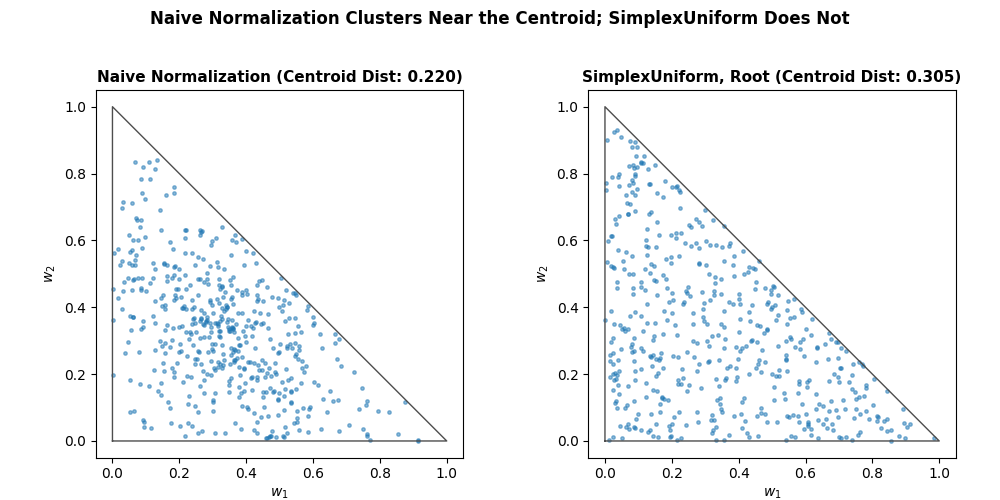

In [5]:
shared = IIDStdUniform(3, seed=0).gen_samples(512)  # one shared (512, 3) batch of cube points
naive_shared = (shared / shared.sum(axis=-1, keepdims=True))[:, :2]  # first two of three normalized coords

# Same shared cube points as naive_shared, so the two panels isolate the map's effect
# (not a sampler difference): take the first two of three coordinates, as naive_shared does.
w = SimplexUniform.transform_points(shared[:, :2], transform_method='root')

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
boundary = np.array([[0, 0], [1, 0], [0, 1], [0, 0]])
panels = [('Naive Normalization', naive_shared), ('SimplexUniform, Root', w)]
for ax, (title, pts) in zip(axes, panels):
    ax.plot(*boundary.T, color='0.3', linewidth=1)
    ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.5)
    centroid_dist = np.mean(np.hypot(pts[:, 0] - 1 / 3, pts[:, 1] - 1 / 3))
    ax.set_title(f'{title} (Centroid Dist: {centroid_dist:.3f})', fontweight='bold', fontsize=11)
    ax.set_xlabel('$w_1$')
    ax.set_ylabel('$w_2$')
    ax.tick_params(labelleft=True, labelbottom=True)  # sharey hides the right panel's labels otherwise
    ax.set_aspect('equal')
fig.suptitle('Naive Normalization Clusters Near the Centroid; SimplexUniform Does Not', fontweight='bold', fontsize=12)
plt.tight_layout()
fig.subplots_adjust(top=0.82)


Normalizing pulls points toward the centroid, while `SimplexUniform` spreads them uniformly across the triangle, corners included.

## 4. The `transform_method` Family

`SimplexUniform` exposes five measure-preserving methods to perform the cube-to-$T_d$ mapping. While all methods maintain the correct distribution, they differ in their continuity and Low-Discrepancy (LD) structure trade-offs [2], [3].

| Method | Description | Pros | Cons |
|---|---|---|---|
| **`root`** (default) | A bijective, closed-form map with no free parameters. | Closed-form, no free parameters to tune. | Displaces points near $x_d=0$ significantly more than those near $x_d=1$. |
| **`sort`** | Simply sorts the coordinates of each point. | Fast. | Can fold nearby cube points onto noticeably different simplex points. |
| **`shift`** | Sorts the coordinates and then removes overlap using a more local rule than `sort`. | Keeps QMCPy's elementary intervals more compact than `root`. | - |
| **`origami`** | Recursively sorts within a grid of sub-cubes. | Guarantees the preservation of every elementary interval's size. | Discontinuous. |
| **`mirror`** | Reflects points into $T_d$ instead of sorting them. | Fast. | Discontinuous. Limited to $d \le 3$; folds any point set symmetric about its center (e.g., a lattice) onto itself. |

The panels below illustrate the effect of each method using the same 256 Sobol' points for $d=2$ (where $K_2$ is the triangle defined by $w_1, w_2 \ge 0, w_1+w_2 \le 1$).

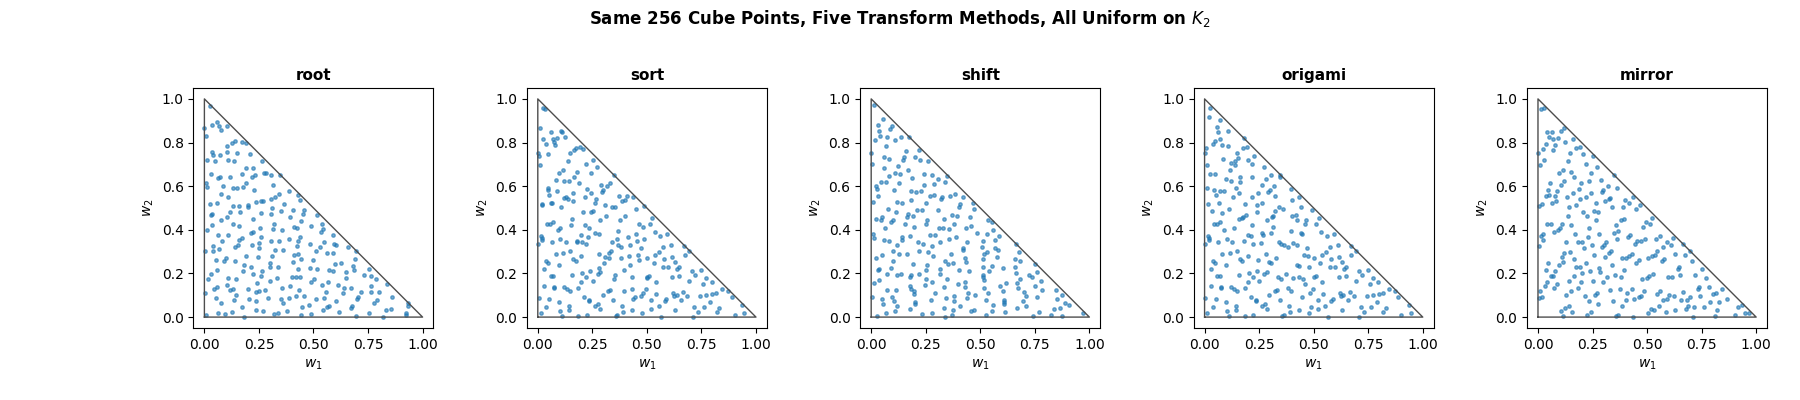

In [6]:
methods = ['root', 'sort', 'shift', 'origami', 'mirror']
fig, axes = plt.subplots(1, len(methods), figsize=(18, 4), sharex=True, sharey=True)
boundary = np.array([[0, 0], [1, 0], [0, 1], [0, 0]])

with warnings.catch_warnings():
    warnings.simplefilter('ignore', UserWarning)  # mirror's d<=3 notice; expected here
    for ax, method in zip(axes, methods):
        w = SimplexUniform(DigitalNetB2(2, seed=7), transform_method=method)(256)
        ax.plot(*boundary.T, color='0.3', linewidth=1)
        ax.scatter(w[:, 0], w[:, 1], s=6, alpha=0.6)
        ax.set_title(method, fontweight='bold', fontsize=11)
        ax.set_xlabel('$w_1$')
        ax.set_ylabel('$w_2$')
        ax.tick_params(labelleft=True, labelbottom=True)  # sharey hides inner panels' labels otherwise
        ax.set_aspect('equal')
fig.suptitle("Same 256 Cube Points, Five Transform Methods, All Uniform on $K_2$", fontweight='bold', fontsize=12)
plt.tight_layout()
fig.subplots_adjust(left=0.10, bottom=0.18, top=0.78)

## 5. `SimplexUniform` as a `TrueMeasure`

Because `SimplexUniform` is a proper `AbstractTrueMeasure`, it slots into QMCPy's integration routines exactly like `Uniform` or `Gaussian`: wrap any discrete distribution or true measure, call it to get weights, and it carries the dimension and sampler of whatever was wrapped.

The cell below draws 8 weights with $d=3$ and checks the support: each row is nonnegative and sums to at most 1, and appending $1-\sum_i w_i$ gives a full probability vector.

In [7]:
sampler = SimplexUniform(DigitalNetB2(3, seed=7), transform_method='root')
w = sampler(8)
print("shape (n, d):", w.shape)
print("all nonnegative:", bool(np.all(w >= 0)))
print("every row sums to <= 1:", bool(np.all(w.sum(axis=-1) <= 1 + 1e-12)))

# Append the implicit (d+1)-th weight for the full probability vector.
v = np.concatenate([w, 1 - w.sum(axis=-1, keepdims=True)], axis=-1)
print("full vector sums to exactly 1:", bool(np.allclose(v.sum(axis=-1), 1)))

shape (n, d): (8, 3)
all nonnegative: True
every row sums to <= 1: True
full vector sums to exactly 1: True


Every `transform_method` targets the same $\mathrm{Dirichlet}(1,\dots,1)$ law. Therefore, their weight means and variances should be consistent with each other and with theory, even though they move individual points differently (Section 4). The cell below verifies this consistency at $d=4$ for the four methods that support it (`mirror` requires $d \le 3$):

In [8]:
d = 4
theo_mean, theo_var = 1 / (d + 1), d / ((d + 1) ** 2 * (d + 2))  # symmetric Dirichlet(1,...,1), d+1 parts

print(f"{'method':<10}{'mean':>10}{'variance':>12}")
print(f"{'theory':<10}{theo_mean:>10.4f}{theo_var:>12.4f}")
for method in ['root', 'sort', 'shift', 'origami']:
    w1 = SimplexUniform(DigitalNetB2(d, seed=7), transform_method=method)(2 ** 15)[..., 0].ravel()  # 32 * 2**10 points, pooled
    print(f"{method:<10}{w1.mean():>10.4f}{w1.var():>12.4f}")

method          mean    variance
theory        0.2000      0.0267
root          0.2000      0.0267
sort          0.2000      0.0267
shift         0.2000      0.0267
origami       0.2000      0.0267


## 6. The Weight/Density Contract

The density of `SimplexUniform` is constant ($d!$) everywhere inside the simplex $K_d$ and exactly $0$ outside it. This property is critical when `SimplexUniform` is used as an importance-sampling target (e.g., `SimplexUniform(Uniform(sampler))`), as points falling outside $K_d$ must contribute zero to the integral.

The cell below evaluates this density at points inside and outside $K_2$, and then verifies that a constant integrand under the composed `SimplexUniform(Uniform(...))` integrates correctly to 1.

In [9]:
sampler = SimplexUniform(DigitalNetB2(2, seed=7))

inside = np.array([[0.2, 0.3], [0.1, 0.1]])
outside = np.array([[0.9, 0.9], [2.0, 2.0], [-0.1, 0.5]])
print("density inside K_2 (constant 2! = 2):", sampler._weight(inside))
print("density outside K_2 (exact 0):       ", sampler._weight(outside))

# Composed as an importance-sampling target: a constant integrand should integrate to 1,
# the probability mass of K_2 under SimplexUniform itself.
ism = SimplexUniform(Uniform(DigitalNetB2(2, seed=11)))
integrand = CustomFun(ism, lambda x: np.ones(x.shape[:-1]))
solution, data = CubQMCNetG(integrand, abs_tol=5e-3).integrate()
print(f"\ncomposed importance-sampling integral (exact 1.0): {solution:.4f}")

density inside K_2 (constant 2! = 2): [2. 2.]
density outside K_2 (exact 0):        [0. 0. 0.]

composed importance-sampling integral (exact 1.0): 1.0000


## 7. A Practical Limit: $d \le 170$

`SimplexUniform`'s density is exactly $d!$, computed as a `float64`. $171!$ has about 310 digits, past `float64`'s roughly $1.8 \times 10^{308}$ ceiling, so dimensions above 170 raise a documented `ParameterError` at construction instead of a bare `OverflowError`.

In [10]:
print("d=170:", SimplexUniform(DigitalNetB2(170, seed=1))(4).shape)
try:
    SimplexUniform(DigitalNetB2(171, seed=1))
except ParameterError as e:
    print("d=171:", e)

d=170: (4, 170)
d=171: SimplexUniform's density d! is not representable as a float64 for dimension 171 (float64 overflows above d=170).


## 8. QMC Convergence

Correctly implementing the cube-to-simplex map ensures that the weights form a genuine measure-preserving image of the cube. This means that the equidistribution properties of an LD point set transfer directly to the simplex, allowing QMC's faster-than-Monte-Carlo convergence to apply [5].

The cell below estimates

$$\mathbb{E}_{w\sim\text{SimplexUniform}}\Big[\sum_{i=1}^d w_i\Big] = \int_{K_d} \Big(\sum_{i=1}^d w_i\Big)\, d!\, dw_1\cdots dw_d = \frac{d}{d+1}$$

over $K_8$ using both IID points and a digital net. This is tested for the four transform methods supporting $d=8$ (`root`, `sort`, `shift`, `origami`; `mirror` needs $d \le 3$), across sample sizes $n = 2^6$ to $2^{18}$, using a single draw per $n$ (no replications): only `root`'s advantage over IID holds at every $n$ below, since a single unreplicated draw is noisy enough that the other methods can occasionally trade places with IID at a particular $n$.

At the largest n, 'root' beats the slowest other method by 27x (single run, no replications).


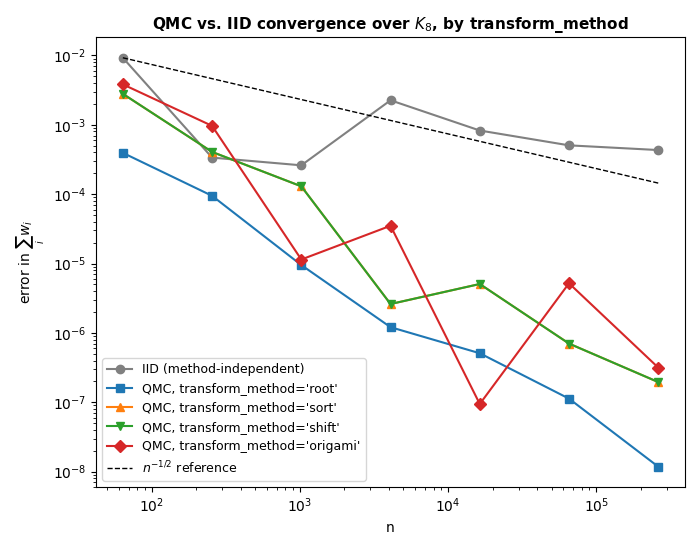

In [11]:
d = 3
exact = d / (d + 1)
ns = [2 ** k for k in range(6, 18, 2)] + [2 ** 18]
# 'mirror' excluded: it only supports dimension <= 3 (d=8 here).
methods = ['root', 'sort', 'shift', 'origami']

iid_err1 = []
for n in ns:
    w_iid1 = SimplexUniform(IIDStdUniform(d, seed=8))(n)
    iid_err1.append(abs(w_iid1.sum(axis=-1).mean(axis=-1) - exact))

qmc_err1 = {method: [] for method in methods}
for method, n in itertools.product(methods, ns):
    w_qmc1 = SimplexUniform(DigitalNetB2(d, seed=7), transform_method=method)(n)
    qmc_err1[method].append(abs(w_qmc1.sum(axis=-1).mean(axis=-1) - exact))

markers = {'root': 's', 'sort': '^', 'shift': 'v', 'origami': 'D'}
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.loglog(ns, iid_err1, 'o-', color='gray', label='IID (method-independent)')
for method in methods:
    ax.loglog(ns, qmc_err1[method], markers[method] + '-', label=f"QMC, transform_method='{method}'")
ax.loglog(ns, iid_err1[0] * (np.array(ns) / ns[0]) ** -0.5, 'k--', linewidth=1, label=r'$n^{-1/2}$ reference')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('n')
ax.set_ylabel(r'error in $\sum_i w_i$')
ax.legend(fontsize=9)
ax.set_title(r"QMC vs. IID convergence over $K_8$, by transform_method",
             fontweight='bold', fontsize=11)
fig.tight_layout()

print(f"At the largest n, 'root' beats the slowest other method by "
      f"{max(qmc_err1[m][-1] for m in methods if m != 'root') / qmc_err1['root'][-1]:.0f}x "
      f"(single run, no replications).")

## 9. Conclusion

`SimplexUniform` turns any QMCPy discrete distribution or true measure into a measure-preserving source of simplex-valued points, with a choice of five cube-to-simplex maps, a well-defined density/support contract for use as an importance-sampling target, and a documented dimension limit. The result is that LD equidistribution, and the faster integration error decay that comes with it, survives the trip from the cube to the simplex intact.

See [`demos/portfolio/portfolio_allocation_demo.ipynb`](../portfolio/portfolio_allocation_demo) for an application to portfolio-weight sampling.

## References

[1] L. Devroye, *Non-Uniform Random Variate Generation*. Springer-Verlag, 1986, Sec. I.4.1.

[2] T. Pillards and R. Cools, "Transforming low-discrepancy sequences from a cube to a simplex," *Journal of Computational and Applied Mathematics*, vol. 174, no. 1, pp. 29-42, 2005.

[3] T. Pillards, "Quasi-Monte Carlo integration over a simplex and the entire space," Ph.D. thesis, KU Leuven, 2006. [Online]. Available: https://www.cs.kuleuven.be/publicaties/doctoraten/tw/TW2006_05.pdf

[4] N. A. Smith and R. W. Tromble, "Sampling uniformly from the unit simplex," Johns Hopkins University, Dept. of Computer Science, Tech. Rep., 2004.

[5] H. Niederreiter, *Random Number Generation and Quasi-Monte Carlo Methods*. SIAM, 1992.

## Appendix: An Interactive Tour

Just for fun: pick any base sampler and any `transform_method` to extend Section 3's static two-panel comparison to three stages, now in 3D and for whichever combination you like.

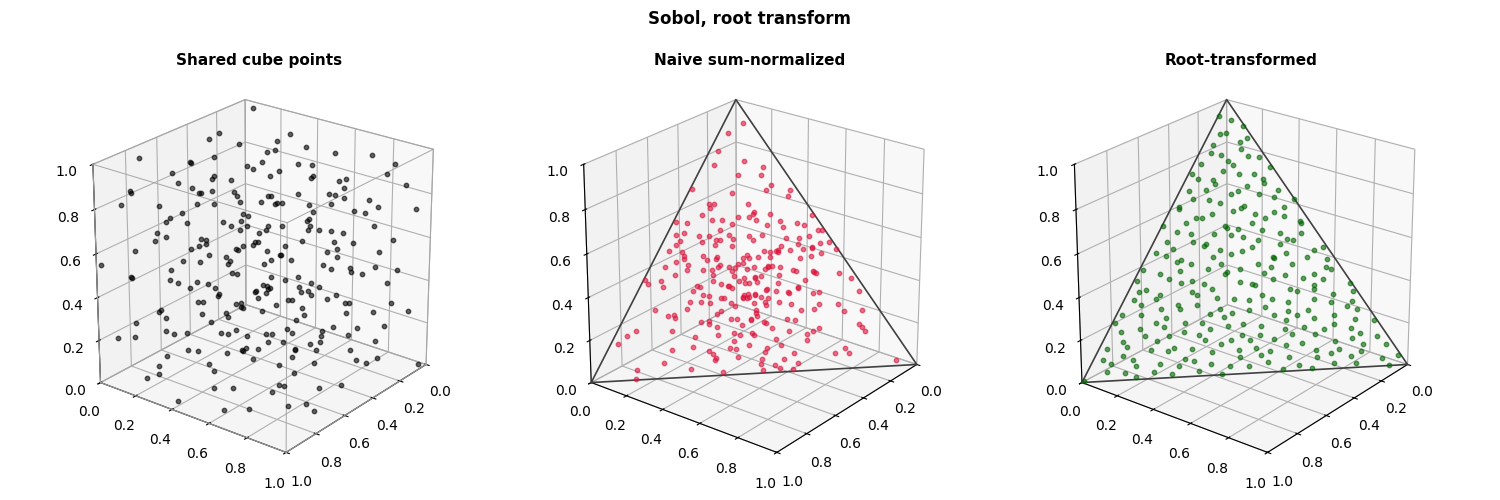

In [12]:
_appendix_samplers = {'IID': IIDStdUniform, 'Lattice': Lattice, 'Sobol': Sobol, 'Halton': Halton, 'DigitalNetB2': DigitalNetB2}
_appendix_methods = ['root', 'sort', 'shift', 'origami', 'mirror']
_appendix_boundary = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 0, 0]])


def plot_cube_normalize_transform(base_sampler, method, n_plot=256, seed=42):
    """Shared cube points / naive-normalized / SimplexUniform-transformed weights, side by side in 3D."""
    cube_points = _appendix_samplers[base_sampler](dimension=3, seed=seed).gen_samples(n_plot)
    naive = cube_points / cube_points.sum(axis=-1, keepdims=True)
    w2 = SimplexUniform(DigitalNetB2(2, seed=seed), transform_method=method)._transform(cube_points[:, :2])
    transformed = np.concatenate([w2, 1 - w2.sum(axis=-1, keepdims=True)], axis=-1)

    stages = [
        ('Shared cube points', cube_points, 'black'),
        ('Naive sum-normalized', naive, 'crimson'),
        (f'{method.capitalize()}-transformed', transformed, 'darkgreen'),
    ]
    fig = plt.figure(figsize=(15, 5))
    for col, (label, points, color) in enumerate(stages):
        ax = fig.add_subplot(1, 3, col + 1, projection='3d')
        ax.scatter(*points.T, s=10, alpha=0.6, color=color, depthshade=False)
        if col == 0:
            for corner, axis in itertools.product(np.ndindex(2, 2, 2), range(3)):
                if corner[axis] == 0:
                    end = list(corner)
                    end[axis] = 1
                    ax.plot(*np.array([corner, end]).T, color='0.65', linewidth=0.7)
        else:
            ax.plot(*_appendix_boundary.T, color='0.25', linewidth=1.2)
        ax.set(xlim=(0, 1), ylim=(0, 1), zlim=(0, 1))
        ax.set_title(label, fontweight='bold', fontsize=11)
        ax.set_box_aspect((1, 1, 1))
        ax.view_init(elev=24, azim=38)
    fig.suptitle(f'{base_sampler}, {method} transform', fontweight='bold', fontsize=12)
    fig.tight_layout(pad=2.0)
    return fig


_appendix_controls = {
    'base_sampler': widgets.Dropdown(description='Sampler', options=list(_appendix_samplers), value='Sobol'),
    'method': widgets.Dropdown(description='Transform', options=_appendix_methods, value='root'),
}
_appendix_display = {'handle': None}


def _update_appendix_plot(_=None):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', UserWarning)  # mirror's d<=3 notice; always true here (d=2)
        fig = plot_cube_normalize_transform(_appendix_controls['base_sampler'].value, _appendix_controls['method'].value)
    if _appendix_display['handle'] is None:
        _appendix_display['handle'] = display(fig, display_id=True)
    else:
        _appendix_display['handle'].update(fig)
    plt.close(fig)


for _control in _appendix_controls.values():
    _control.observe(_update_appendix_plot, names='value')

display(widgets.VBox([*_appendix_controls.values()]))
_update_appendix_plot()